# **ConvNet 2D** example

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
    
# ---------------------------
# 1. Device
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "mps")
print("Using device:", device)

Using device: mps


## Dataset and data loader

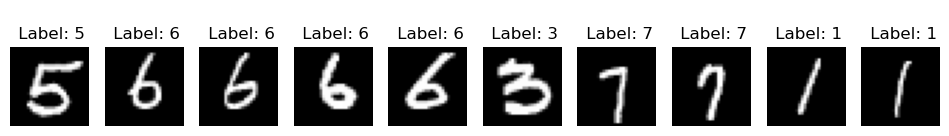

In [12]:

# ---------------------------
# 2. Dataset
# ---------------------------
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=True)


    

### Visualise some images

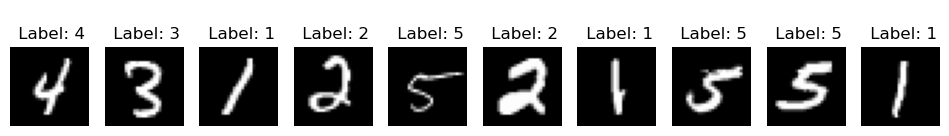

In [14]:

images, labels = next(iter(train_loader))
images = images.to(device)
images = images.cpu()

plt.figure(figsize=(12, 4))
n_images=10
for i in range(n_images):
    plt.subplot(1, n_images, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"\n Label: {labels[i].item()}")
    plt.axis("off")

plt.show()

## Model

In [5]:

# ---------------------------
# 3. Model
# ---------------------------
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(16 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x



## Learning

In [6]:



model = SimpleCNN().to(device)

# ---------------------------
# 4. Loss + optimizer
# ---------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ---------------------------
# 5. Training
# ---------------------------
def train(model, loader):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss


# ---------------------------
# 6. Evaluation
# ---------------------------
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total


# ---------------------------
# 7. Visualization
# ---------------------------
def show_predictions(model, loader, n_images=6):
    model.eval()

    images, labels = next(iter(loader))
    images = images.to(device)

    with torch.no_grad():
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

    images = images.cpu()

    plt.figure(figsize=(12, 4))

    for i in range(n_images):
        plt.subplot(1, n_images, i + 1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        plt.title(f"Pred: {preds[i].item()}\nTrue: {labels[i].item()}")
        plt.axis("off")

    plt.show()


    
   
MODEL_PATH = "CNN_model.pth"


if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
    model.eval()  # inference mode
    print("Model loaded. No learning required")
else:
    print("No saved model found. Learning from scratch.")
    
    # ---------------------------
    # 8. Training loop
    # ---------------------------
    epochs = 5

    for epoch in range(epochs):
        loss = train(model, train_loader)
        acc = evaluate(model, test_loader)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, Accuracy={acc:.2f}%")

    # Save only the weights
    torch.save(model.state_dict(), MODEL_PATH)

    print(f"Model saved to {MODEL_PATH}")




Model loaded.


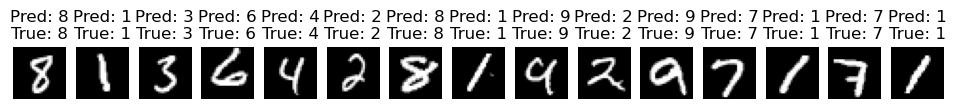

In [8]:

# ---------------------------
# 9. Visualize predictions
# ---------------------------
show_predictions(model, test_loader, n_images=15)



